In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(0)
X=np.sort(5*np.random.rand(80,1),axis=0)
y=np.sin(X).ravel()+np.random.normal(0,0.1,X.shape[0])

In [ ]:
X

array([[0.093949  ],
       [0.10109199],
       [0.19593896],
       [0.30112736],
       [0.35518029],
       [0.4356465 ],
       [0.48049204],
       [0.48550638],
       [0.51022405],
       [0.55187571],
       [0.59137213],
       [0.59363859],
       [0.60098281],
       [0.64463149],
       [0.69091476],
       [0.71676644],
       [0.79484792],
       [0.80654759],
       [0.98291181],
       [1.04438378],
       [1.05191281],
       [1.22212796],
       [1.26645801],
       [1.32277806],
       [1.41403481],
       [1.48070099],
       [1.57714175],
       [1.7975395 ],
       [1.81855385],
       [1.84362585],
       [1.91720759],
       [2.0733097 ],
       [2.118274  ],
       [2.18515977],
       [2.18793606],
       [2.19300757],
       [2.28075166],
       [2.30739681],
       [2.33155386],
       [2.34325601],
       [2.60924161],
       [2.6444746 ],
       [2.72441591],
       [2.74406752],
       [2.84022281],
       [2.84216974],
       [2.85098385],
       [3.013

In [ ]:
y

array([ 0.01249623, -0.07170837,  0.21243023,  0.25641893,  0.18473957,
        0.46827483,  0.37148572,  0.47185082,  0.56128183,  0.53718368,
        0.67144073,  0.43589821,  0.60568751,  0.53242291,  0.5501627 ,
        0.59906525,  0.68260184,  0.72751897,  0.71560081,  0.95469774,
        0.91493964,  0.78620413,  1.10287066,  1.15898973,  1.10561601,
        0.97795168,  0.89290461,  1.07984889,  0.92914709,  1.08525682,
        0.96142473,  0.97403872,  0.88947684,  0.88779787,  0.81658704,
        0.99117871,  0.7710822 ,  0.78095548,  0.91262899,  0.58142032,
        0.38051194,  0.57383408,  0.2878686 ,  0.58149977,  0.2554667 ,
        0.22022336,  0.47882976,  0.27547984,  0.30385169,  0.17162959,
       -0.02923063,  0.24439627, -0.08478026, -0.00751921, -0.02890664,
       -0.15509888, -0.12965108, -0.11780058, -0.22668715, -0.44960755,
       -0.39100082, -0.39407117, -0.73601025, -0.69601013, -0.73319984,
       -0.54419177, -0.68681633, -0.78037549, -0.92988715, -0.81

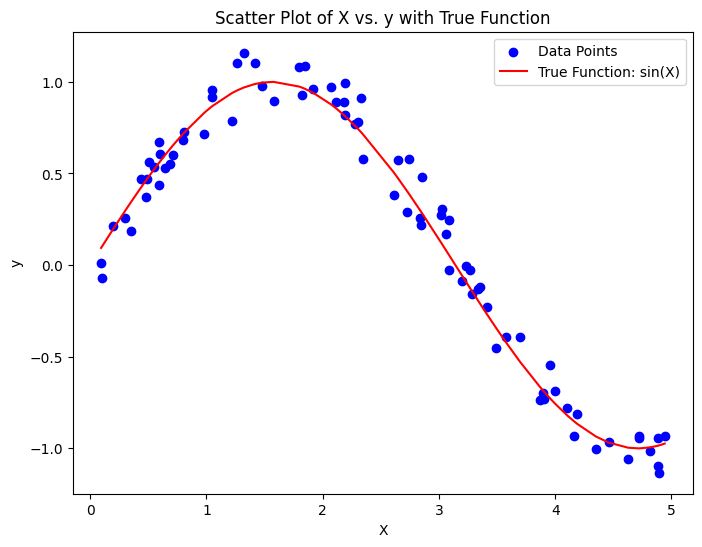

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', label='Data Points')
plt.plot(X, np.sin(X), color='red', label='True Function: sin(X)')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Scatter Plot of X vs. y with True Function')
plt.legend()
plt.show()

In [ ]:
def locally_weighted_regression(query_point, X, y, tau):

    m = X.shape[0]
    X_ = np.hstack((np.ones((m, 1)), X))
    query_point_ = np.array([1, query_point])

    weights = np.exp(-np.sum((X - query_point)**2, axis=1) / (2 * tau**2))
    W = np.diag(weights)
    theta = np.linalg.pinv(X_.T @ W @ X_) @ (X_.T @ W @ y)

    prediction = query_point_ @ theta
    return prediction

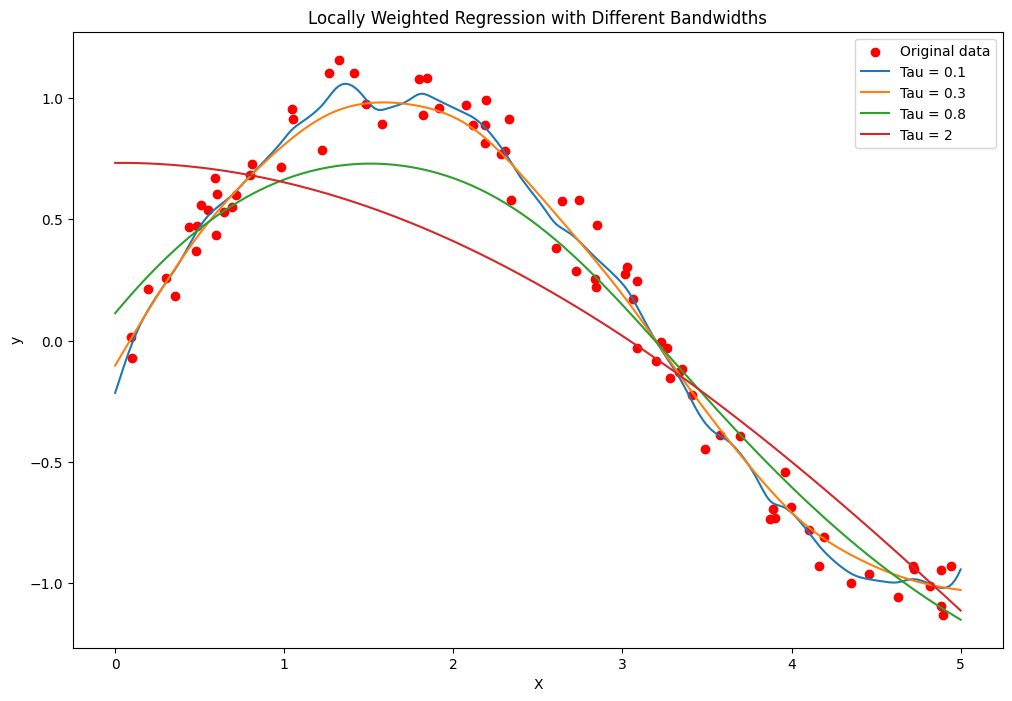

In [ ]:
tau_values = [0.1, 0.3, 0.8, 2]
query_points = np.linspace(0, 5, 300)

plt.figure(figsize=(12, 8))
plt.scatter(X, y, color='red', label='Original data')

for tau in tau_values:
    y_pred = [locally_weighted_regression(point, X, y, tau) for point in query_points]
    plt.plot(query_points, y_pred, label=f'Tau = {tau}')

plt.title('Locally Weighted Regression with Different Bandwidths')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()